## Global configuration

In [9]:
dataset_root = "../datasets"

import sys
sys.path.append("../src/")  # analytics package

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Global Seed for Reproducibility

In [10]:
import torch
import numpy as np
import random
import os


def set_reproducibility(seed: int = 42):
    """Sets all seeds and forces deterministic behavior in PyTorch."""
    # 1. Basic Python and Environment
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # 2. NumPy
    np.random.seed(seed)

    # 3. PyTorch (CPU and all GPUs)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for multi-GPU

    # 4. Force Deterministic Algorithms
    # This ensures that PyTorch operations (like convolutions or complex loss functions)
    # always produce the same result, though it may slightly reduce performance.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Reproducibility set with seed: {seed}")


# ensure reproducibility to be able to compare different FL strategies in different runs
set_reproducibility(42)

Reproducibility set with seed: 42


## Dataset loading and preparation

In [11]:
import pyarrow.compute as pc
from tls_profiling.preprocessing import build_and_fit_preprocessor, extract_features
from tls_profiling.io import open_tls_parquet_dataset

dataset = open_tls_parquet_dataset(f"{dataset_root}/malware.parquet")

filt = (
    pc.starts_with(
        pc.field("meta.sample.id"), "25090"
    )  # use meta.sample.id to get only a single day 2025-09-01
)

print(f"Loading dataset...filter={filt}")
df = dataset.to_table(filter=filt).to_pandas()

df.head(10)

Loading dataset...filter=starts_with(meta.sample.id, {pattern="25090", ignore_case=false})


,bs,ps,br,pr,dp,sp,da,sa,ts,td,...,tls.ja4,tls.ja3s,tls.ja4s,meta.sample.id,meta.malware.family,meta.system.os,meta.system.service,meta.application.name,meta.application.process,tls.rec
0,1262,13,8316,12,443,49792,20.72.205.209,10.127.0.189,1.756762e+09,0.941528,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -2..."
1,49974,64,39987,54,443,49801,40.126.31.67,10.127.0.189,1.756762e+09,128.561234,...,t12d1909h2_d83cc789557e_7af1ed941c26,7d8fd34fdb13a7fff30d5a52846b6c4c,t120400_c030_09f674154ab3,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,None,None,None,"[-226, 3954, -102, -1, -40, 1, 40, -445, -3616..."
2,35832,48,31235,40,443,49803,40.126.31.67,10.127.0.189,1.756762e+09,138.264477,...,t12d1909h2_d83cc789557e_7af1ed941c26,7d8fd34fdb13a7fff30d5a52846b6c4c,t120400_c030_09f674154ab3,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,None,None,None,"[-226, 3954, -102, -1, -40, 1, 40, -469, -7637..."
3,4529,14,8280,14,443,49804,20.72.205.209,10.127.0.189,1.756762e+09,1.195099,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
4,4035,14,4910,13,443,49806,52.167.17.97,10.127.0.189,1.756762e+09,0.749950,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
5,1982,13,4870,12,443,49807,52.167.17.97,10.127.0.189,1.756762e+09,0.683508,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -9..."
6,2437,19,21862,25,443,49808,52.167.17.97,10.127.0.189,1.756762e+09,0.657093,...,t12d1909h2_d83cc789557e_7af1ed941c26,2fe9b0e731d3d41b2b84e8e1d6186836,t1204h2_c030_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_telemetry,None,None,"[-211, 3753, -102, -1, -40, 1, 40, 64, -82, -1..."
7,1775,25,28988,27,443,49860,74.178.76.128,10.127.0.189,1.756762e+09,0.216118,...,t12d1909h2_d83cc789557e_7af1ed941c26,a02d7ceb8c8cbb4da2e6007f5a1c91e4,t1203h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_core,None,None,"[-206, 2488, -102, -1, -40, 1, 40, -82, -264, ..."
8,1134,13,3326,10,443,49861,13.95.31.18,10.127.0.189,1.756762e+09,0.235395,...,t12d1909h2_d83cc789557e_7af1ed941c26,87b9bed0515be16c82bdc44d88a4a0ec,t1204h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_delivery,None,None,"[-211, 2550, -102, -1, -40, 1, 40, 64, -82, -9..."
9,996,10,3239,8,443,49862,74.178.76.128,10.127.0.189,1.756762e+09,0.173583,...,t12d1909h2_d83cc789557e_7af1ed941c26,a02d7ceb8c8cbb4da2e6007f5a1c91e4,t1203h2_c02c_5333cdffa7d9,250901-1aw26afr2z_behavioral1,None,windows10-2004-x64,microsoft_core,None,None,"[-206, 2487, -102, -1, -40, 1, 40, -82, -85, 5..."


## Preprocessing & Data Partitioning

In [ ]:
VAL_RATIO = 0.2
TEST_RATIO = 0.2
ENCODING_DIM = 10
TARGET_FAMILY = "ades_stealer"
num_nodes = 5

import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tls_profiling.preprocessing.malware_families import get_families, per_family_split


# Get the first family and its data
families = get_families(df)
splits = per_family_split(df, families, test_size=TEST_RATIO)
pre_train_df, test_df = splits[TARGET_FAMILY]

# Preprocess the entire family data to establish the feature space
pipeline = build_and_fit_preprocessor(extract_features(pre_train_df))
X_train_full = pipeline.transform(extract_features(pre_train_df))
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = np.clip(scaler.fit_transform(X_train_full), 0, 1)
input_dim: int = X_train_scaled.shape[1]

# Data partitioning; results FL train_loss, independent test_loss
# no field (random): 0.035088 0.034241
# field "sa" on one day data: 0.025793 5.558623
field_to_split: str | None = None
if field_to_split is not None:
    # Split the training data based on the field
    grouped_indices = pre_train_df.groupby(field_to_split).indices
    partitions = [X_train_scaled[idx] for idx in grouped_indices.values()]
else:
    # Shuffle and split the training data into NUM_NODES partitions
    indices = np.random.permutation(len(X_train_scaled))
    partitions = np.array_split(X_train_scaled[indices], num_nodes)

valid_partitions = [p for p in partitions if len(p) > 0]

print(f"Created {len(valid_partitions)} partitions based on '{field_to_split}' field.")
if len(valid_partitions) < num_nodes:
    print(
        f"Warning: Only {len(valid_partitions)} out of original {num_nodes} nodes will have data/partitions; reducing the number of nodes to match the partitions."
    )
    num_nodes = len(valid_partitions)

Created 5 partitions based on 'None' field.


## The Simulation Setup

In [13]:
TRAINING_EPOCHS = 3  # local
TRAINING_ROUNDS = 50  # federated

import gc
import ray
from flwr.client import ClientApp
from flwr.common import Context, Scalar, parameters_to_ndarrays
from flwr.server import ServerApp, ServerAppComponents, ServerConfig, strategy
from flwr.simulation import run_simulation
from torch import nn

from tls_profiling.federated.flower_client import FlowerClient

# Global store for federated fit/eval histories
# as the run_simulation() is not returning the history with metrics, we will provide the recording strategy to build the history incrementaly
fed_fit_history = []
fed_eval_history = []

# Global storage for models
# Key: family_name, Value: list of numpy arrays (weights)
trained_global_models = {}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class RecordingStrategy(strategy.FedAvg):
    def aggregate_fit(self, server_round, results, failures):
        params, metrics = super().aggregate_fit(server_round, results, failures)
        if metrics:
            fed_fit_history.append((server_round, params, metrics))
        if params is not None and server_round == TRAINING_ROUNDS:
            ndarrays = parameters_to_ndarrays(params)
            trained_global_models[TARGET_FAMILY] = ndarrays
            print(f"Final weights for {TARGET_FAMILY} captured in global memory.")
        return params, metrics

    def aggregate_evaluate(self, server_round, results, failures):
        loss, metrics = super().aggregate_evaluate(server_round, results, failures)
        if metrics:
            fed_eval_history.append((server_round, loss, metrics))
        return loss, metrics


def aggregate_weighted_average(metrics):
    total_examples = sum(num for num, _ in metrics)
    combined_results: dict[str, Scalar] = {}
    all_keys = metrics[0][1].keys()
    for key in all_keys:
        weighted_sum = sum(num * float(m[key]) for num, m in metrics)
        combined_results[key] = float(weighted_sum / total_examples)
    return combined_results


def on_fit_config_fn(server_round: int):
    """Return training configuration dict for each round with LR decay."""
    initial_lr = 1e-3
    decay_factor = 0.5 ** (
        server_round // 20  # Decay the learning rate by half every 20 rounds
    )
    current_lr = initial_lr * decay_factor
    config: dict[str, Scalar] = {
        "local_epochs": TRAINING_EPOCHS,
        "batch_size": 32,
        "lr": current_lr,  # Pass the decayed LR to clients
    }
    if server_round % 10 == 0 or server_round == 1:
        print(f"Round {server_round}: Configured LR = {current_lr:.6f}")
    return config


def client_fn(context: Context):
    p_id = int(context.node_config["partition-id"])
    return FlowerClient(
        partitions[p_id],
        input_dim,
        ENCODING_DIM,
        VAL_RATIO,
        nn.BCELoss(),
        device,
    ).to_client()


def server_fn(context: Context):
    fl_strategy = RecordingStrategy(
        fraction_fit=1.0,  # Train on 100% of nodes in each training round
        min_fit_clients=num_nodes,  # Wait for all nodes to start training
        fraction_evaluate=1.0,  # Evaluate on 100% of nodes
        min_evaluate_clients=num_nodes,  # Wait for all nodes to evaluate
        min_available_clients=num_nodes,  # Minimum number of available clients needed to start a round
        fit_metrics_aggregation_fn=aggregate_weighted_average,  # From the training data on the nodes, how the nodes are actually learning locally
        evaluate_metrics_aggregation_fn=aggregate_weighted_average,  # From the validation data, how the "Global Model" is performing after the weights have been averaged
        on_fit_config_fn=on_fit_config_fn,
    )
    server_config = ServerConfig(num_rounds=TRAINING_ROUNDS)
    return ServerAppComponents(strategy=fl_strategy, config=server_config)


client_app = ClientApp(client_fn=client_fn)
server_app = ServerApp(server_fn=server_fn)

print(
    f"Starting Federated Learning for {TARGET_FAMILY} across {num_nodes} nodes in {TRAINING_ROUNDS} rounds, {TRAINING_EPOCHS} epochs each ..."
)
try:
    # https://flower.ai/docs/framework/1.27/en/how-to-run-simulations.html#simulation-in-colab-jupyter
    run_simulation(
        server_app=server_app,
        client_app=client_app,
        num_supernodes=num_nodes,
        backend_config={
            "client_resources": {
                "num_cpus": 2,  # Each virtual client gets 2 CPU cores
                "num_gpus": 0.2  # Each virtual client gets 20% of your GPU if available
                if torch.cuda.is_available()
                else 0,
            }
        },
    )
finally:
    # This ensures Ray is shut down even if the cell crashes
    if ray.is_initialized():
        ray.shutdown()
        print("Ray runtime shut down successfully.")
    # This clears Python garbage collector and PyTorch CUDA cache
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    print("GPU memory cache cleared.")

INFO :      Starting Flower ServerApp, config: num_rounds=50, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client


Starting Federated Learning for ades_stealer across 5 nodes in 50 rounds, 3 epochs each ...


(pid=gcs_server) [2026-03-25 23:21:11,881 E 422203 422203] (gcs_server) gcs_server.cc:303: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(raylet) [2026-03-25 23:21:13,843 E 422403 422403] (raylet) main.cc:979: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(pid=424015) 2026-03-25 23:21:14.646038: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
(pid=424015) To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[2026-03-25 23:21:30,316 E 398142 422474] core_worker_process

Round 1: Configured LR = 0.001000


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)
INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)
INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)
INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)
INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)
INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)
INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled

...

Round 40: Configured LR = 0.000250


INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [ROUND 41]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)
INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)
INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [ROUND 42]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)
INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)
INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [ROUND 43]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)
INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)
INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [ROUND 44]
INFO

Round 50: Configured LR = 0.000250
Final weights for ades_stealer captured in global memory.


INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 50 round(s) in 18.06s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.4270159125328064
INFO :      		round 2: 0.21187613010406495
INFO :      		round 3: 0.09110484719276428
INFO :      		round 4: 0.07141205668449402
INFO :      		round 5: 0.06220776736736298
INFO :      		round 6: 0.05565098002552986
INFO :      		round 7: 0.051710592955350874
INFO :      		round 8: 0.04951076805591583
INFO :      		round 9: 0.04778982549905777
INFO :      		round 10: 0.04626809433102608
INFO :      		round 11: 0.045087100565433504
INFO :      		round 12: 0.04385418221354485
INFO :      		round 13: 0.0427534393966198
INFO :      		round 14: 0.041786092519760135
INFO :      		round 15: 0.04099474623799324
INFO :      		round 16: 0.04036923199892044
INFO :      		round 17: 0.03988801687955856
INFO :      		round 18: 0.03950800448656082
INFO :      		round 19: 0.

GPU memory cache cleared.


## History Visualisation

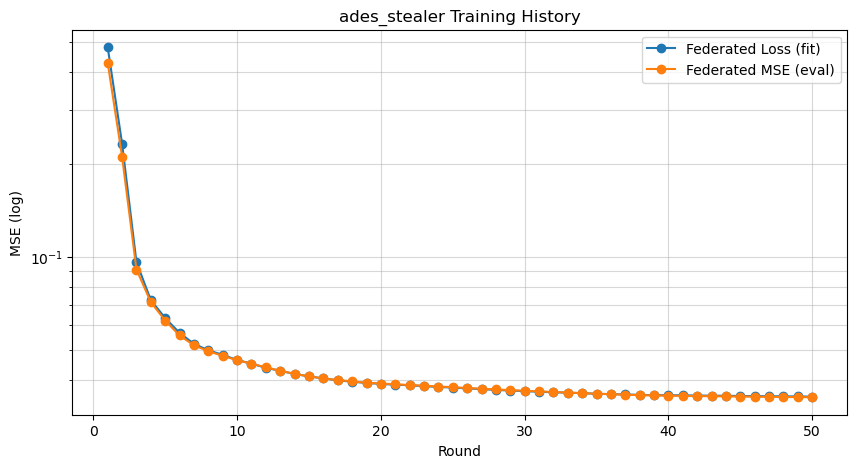

In [14]:
import matplotlib.pyplot as plt

rounds = [item[0] for item in fed_eval_history]
losses = [item[1] for item in fed_eval_history]
train_losses = [item[2]["train_loss"] for item in fed_fit_history]
mses = [item[2]["mse"] for item in fed_eval_history]

plt.figure(figsize=(10, 5))
plt.plot(rounds, train_losses, marker="o", label="Federated Loss (fit)")
plt.plot(rounds, mses, marker="o", label="Federated MSE (eval)")
plt.title(f"{TARGET_FAMILY} Training History")
plt.xlabel("Round")
plt.ylabel("MSE (log)")
plt.yscale("log")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

## Global Model Evaluation for the Same Family

In [15]:
from collections import OrderedDict
from tls_profiling.autoencoder.models_torch import Net
from tls_profiling.autoencoder.train_torch import evaluate_model

# Get the global model from our global dictionary
eval_model = Net(input_dim=input_dim, encoding_dim=10).to(device)
weights = trained_global_models[TARGET_FAMILY]
params_dict = zip(eval_model.state_dict().keys(), weights)
state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
eval_model.load_state_dict(state_dict)
eval_model.eval()

# Prepare test data
X_test_raw = extract_features(test_df)
X_test_transformed = pipeline.transform(X_test_raw)
X_test_scaled = np.clip(scaler.transform(X_test_transformed), 0, 1)

# Evaluate the global model
final_test_loss = evaluate_model(
    model=eval_model, data_loader=X_test_scaled, criterion=nn.BCELoss(), device=device
)

print(f"Final Evaluation of {TARGET_FAMILY}:")
print(f"- Training/Val Loss (last FL round): {mses[-1]:.6f}")
print(f"- Independent Test Loss (test_df):  {final_test_loss:.6f}")

Final Evaluation of ades_stealer:
- Training/Val Loss (last FL round): 0.035088
- Independent Test Loss (test_df):  0.034241


## Global Model Evaluation for Other Families

In [16]:
import pandas as pd
from tls_profiling.autoencoder.train_torch import compute_recon_error

# Define threshold based on successful reconstructions from (greater than) errors on the "Known" test set (test_df of the target family)
target_errors = compute_recon_error(
    eval_model, X_test_scaled, nn.BCELoss(), device=device
)
mean_error = np.mean(target_errors)
std_error = np.std(target_errors)
fixed_threshold = mean_error + (2 * std_error)

print(f"Statistics for {TARGET_FAMILY} model:")
print(f"  Mean Reconstruction Error: {mean_error:.6f}")
print(f"  Detection Threshold:       {fixed_threshold:.6f}")
print()


results = []

for family_name in splits.keys():
    # Load test data for the current family in the loop
    _, current_test_df = splits[family_name]

    # Preprocess
    X_raw = extract_features(current_test_df)
    X_transformed = pipeline.transform(X_raw)
    X_scaled = np.clip(scaler.transform(X_transformed), 0, 1)

    # Get individual errors for this family's data using the Target Model
    current_errors = compute_recon_error(eval_model, X_scaled, nn.BCELoss(), device)

    # Logic check:
    # If it's the target family -> errors ABOVE threshold are False Negatives
    # If it's any other family -> errors BELOW threshold are False Positives
    if family_name == TARGET_FAMILY:
        fn_count = np.sum(current_errors > fixed_threshold)
        fn_rate = (fn_count / len(current_errors)) * 100
        results.append(
            {
                "Family": family_name,
                "Type": "Target",
                "Count": fn_count,
                "Rate (%)": round(fn_rate, 2),
                "Status": "FN",
            }
        )
    else:
        fp_count = np.sum(current_errors <= fixed_threshold)
        fp_rate = (fp_count / len(current_errors)) * 100
        results.append(
            {
                "Family": family_name,
                "Type": "Stranger",
                "Count": fp_count,
                "Rate (%)": round(fp_rate, 2),
                "Status": "FP",
            }
        )

# Display as a clean DataFrame
report_df = pd.DataFrame(results)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(report_df.sort_values("Rate (%)"))

Statistics for ades_stealer model:
  Mean Reconstruction Error: 0.034241
  Detection Threshold:       0.052672



,Family,Type,Count,Rate (%),Status
4,aurotun,Stranger,0,0.00,FP
22,emotet,Stranger,0,0.00,FP
29,hijackloader,Stranger,0,0.00,FP
0,ades_stealer,Target,21,3.79,FN
6,babylonrat,Stranger,6,25.00,FP
43,nightingale,Stranger,8,36.36,FP
53,revengerat,Stranger,6,42.86,FP
9,blankgrabber,Stranger,49,47.12,FP
31,koiloader,Stranger,48,48.00,FP
8,blackmoon,Stranger,88,48.35,FP
